In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from DL.models import CustomClassifierFromConfig
from DL.trainer import ModelTrainer
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator

# Визуализация
from DL.visualize import (show_batch, visualize_all_classes_gradcam,
                          plot_confusion_matrices, visualize_failure_cases)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


C:\Users\Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SyntheticCyrillicDataset(Dataset):
    def __init__(self, num_samples: int, seed: int):
        self.num_samples = num_samples
        self.generator = LowerCaseLettersGenerator(seed=seed)
        self.char_to_idx = {char: idx for idx, char in enumerate(self.generator.ALLOWS_SYMBOLS)}
        self.idx_to_char = {idx: char for char, idx in self.char_to_idx.items()}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img_np, label_char = self.generator.generate()
        img_tensor = torch.from_numpy(img_np).float().unsqueeze(0) / 255.0
        label_idx = self.char_to_idx[label_char]
        return img_tensor, label_idx

train_dataset = SyntheticCyrillicDataset(num_samples=60000, seed=42)
val_dataset = SyntheticCyrillicDataset(num_samples=15000, seed=999)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [3]:
with open('configs/lenet_4kb.json', 'r') as f:
    config = json.load(f)

model_baseline = CustomClassifierFromConfig(config)
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

trainer_baseline = ModelTrainer(
    model=model_baseline, optimizer=optimizer, criterion=criterion,
    device=device, use_background_loss=False
)
print("Обучение Baseline...")
_ = trainer_baseline.fit(train_loader, val_loader, epochs=5)

Обучение Baseline...
Epoch 1/5


Train Loss: 1.6948 | Train Acc: 0.7020 | BG Loss: 0.0000
Val Loss: 0.4629 | Val Acc: 0.9541

Epoch 2/5


Train Loss: 0.2549 | Train Acc: 0.9676 | BG Loss: 0.0000
Val Loss: 0.1463 | Val Acc: 0.9786

Epoch 3/5


Train Loss: 0.1096 | Train Acc: 0.9817 | BG Loss: 0.0000
Val Loss: 0.0867 | Val Acc: 0.9835

Epoch 4/5


Train Loss: 0.0701 | Train Acc: 0.9858 | BG Loss: 0.0000
Val Loss: 0.0605 | Val Acc: 0.9860

Epoch 5/5


Train Loss: 0.0523 | Train Acc: 0.9877 | BG Loss: 0.0000
Val Loss: 0.0477 | Val Acc: 0.9877



In [4]:
model_bg = CustomClassifierFromConfig(config)
optimizer_bg = torch.optim.Adam(model_bg.parameters(), lr=1e-3)

trainer_bg = ModelTrainer(
    model=model_bg, optimizer=optimizer_bg, criterion=criterion,
    device=device, use_background_loss=True, bg_loss_alpha=15.0, bg_loss_n=2
)
print("Обучение с BG Loss...")
_ = trainer_bg.fit(train_loader, val_loader, epochs=5)

Обучение с BG Loss...
Epoch 1/5


Train Loss: 1.9749 | Train Acc: 0.6780 | BG Loss: 0.2568
Val Loss: 0.5283 | Val Acc: 0.9369

Epoch 2/5


Train Loss: 0.3006 | Train Acc: 0.9608 | BG Loss: 0.0000
Val Loss: 0.1806 | Val Acc: 0.9727

Epoch 3/5


Train Loss: 0.1323 | Train Acc: 0.9776 | BG Loss: 0.0000
Val Loss: 0.0992 | Val Acc: 0.9814

Epoch 4/5


Train Loss: 0.0838 | Train Acc: 0.9828 | BG Loss: 0.0000
Val Loss: 0.0654 | Val Acc: 0.9871

Epoch 5/5


Train Loss: 0.0588 | Train Acc: 0.9877 | BG Loss: 0.0000
Val Loss: 0.0506 | Val Acc: 0.9904



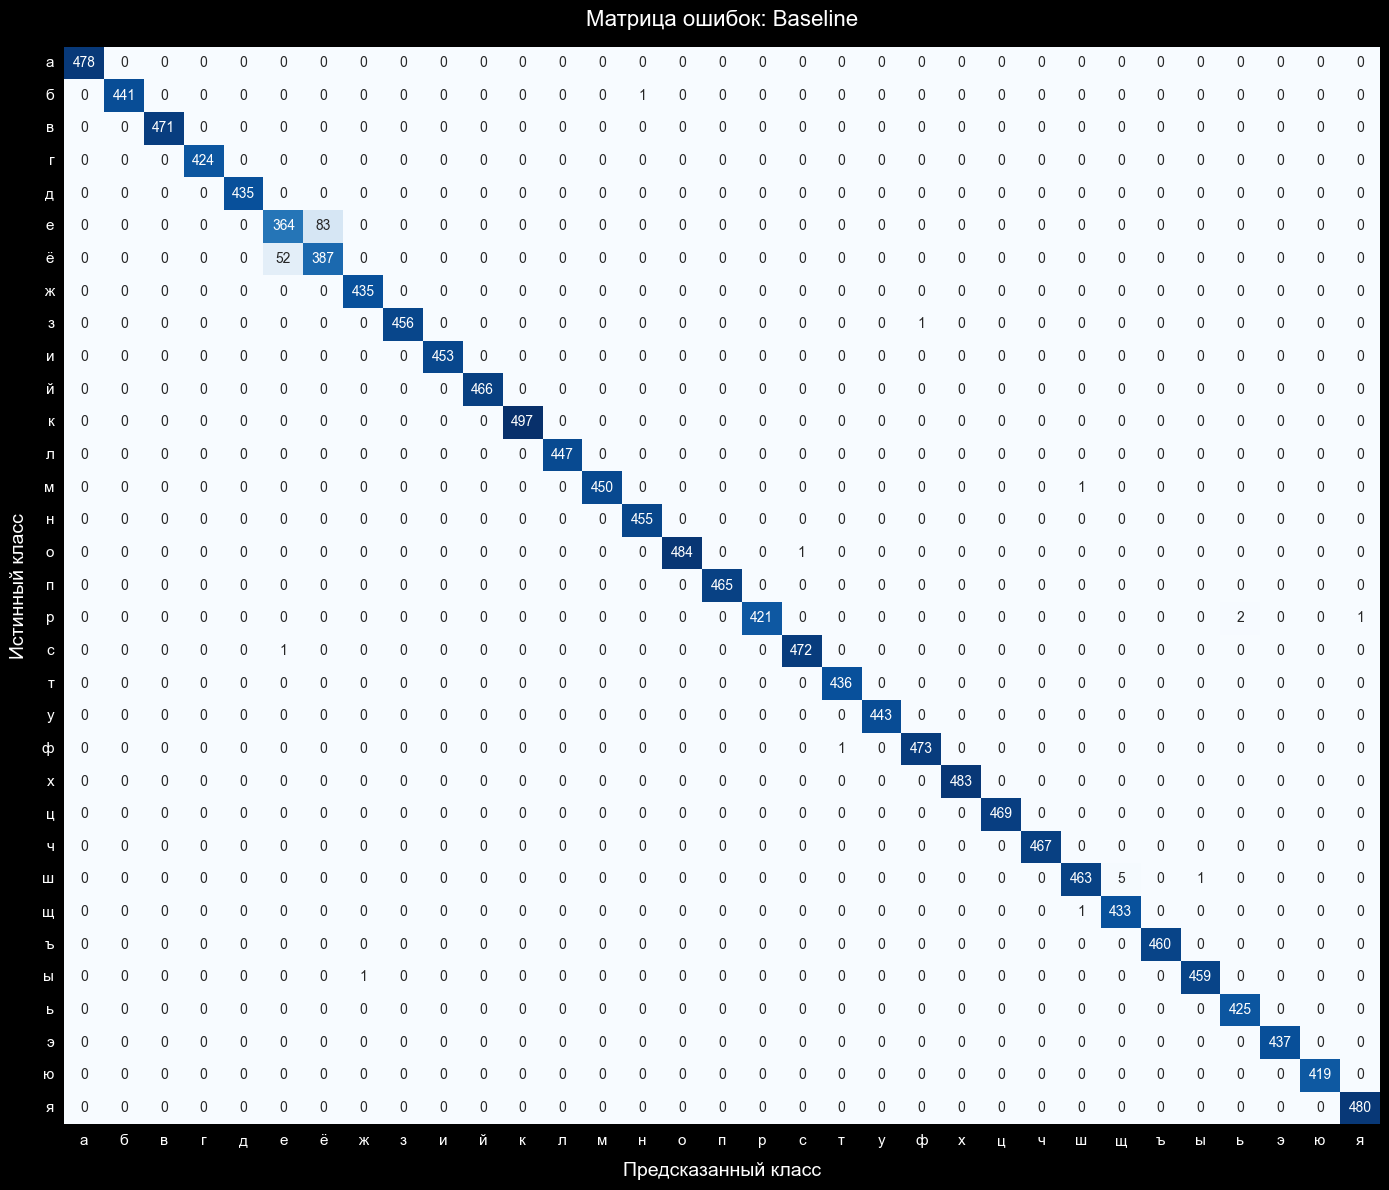

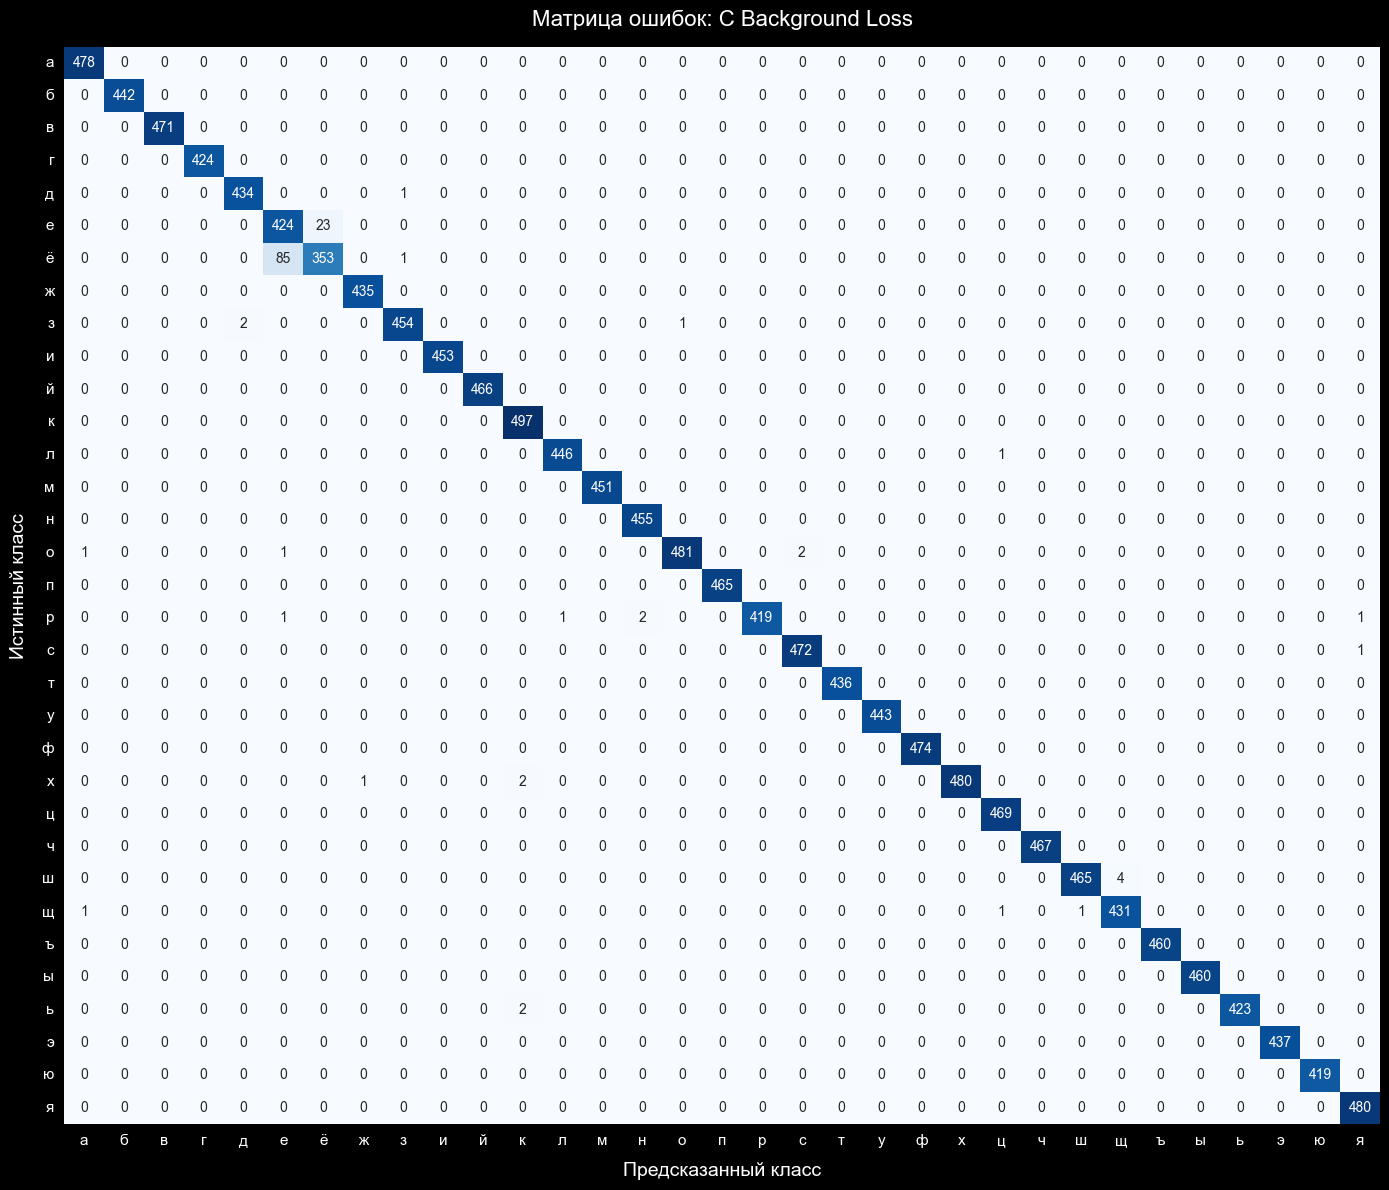

In [5]:
# 1. Матрица ошибок с числами
plot_confusion_matrices(model_baseline, model_bg, val_loader, val_dataset, device)

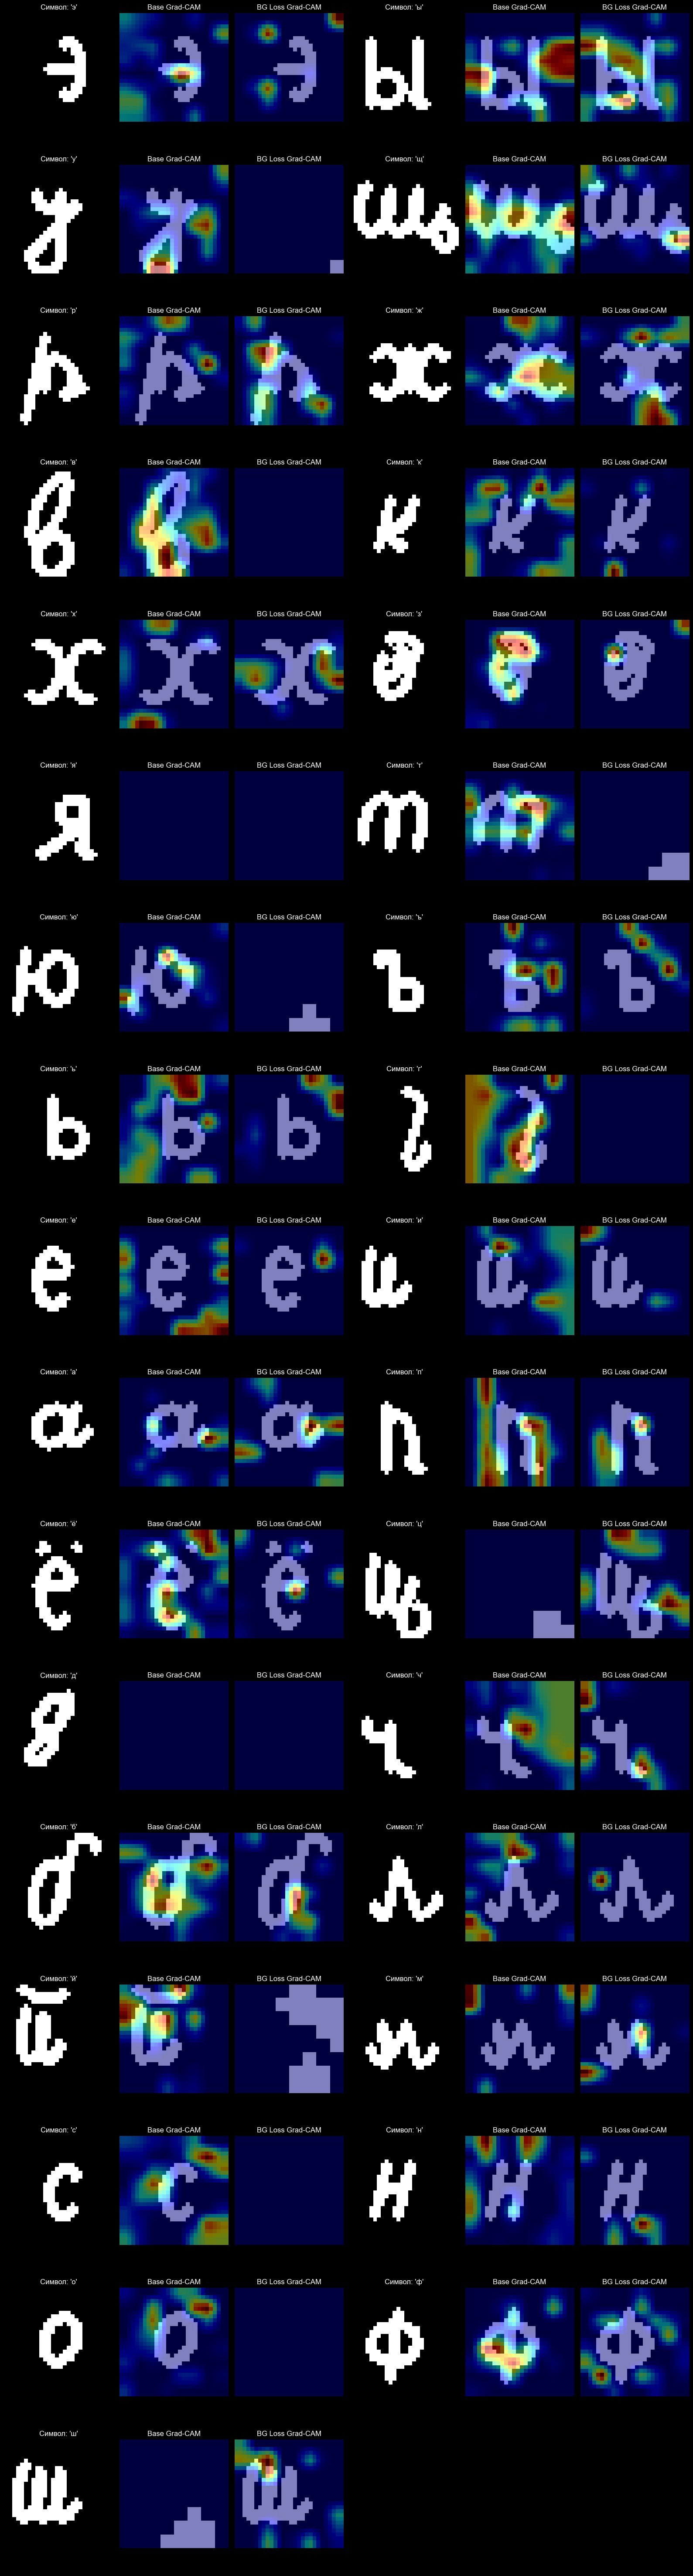

In [6]:
# 2. Отрисовка Grad-CAM
visualize_all_classes_gradcam(model_baseline, model_bg, val_dataset, device)

Ошибки Baseline:


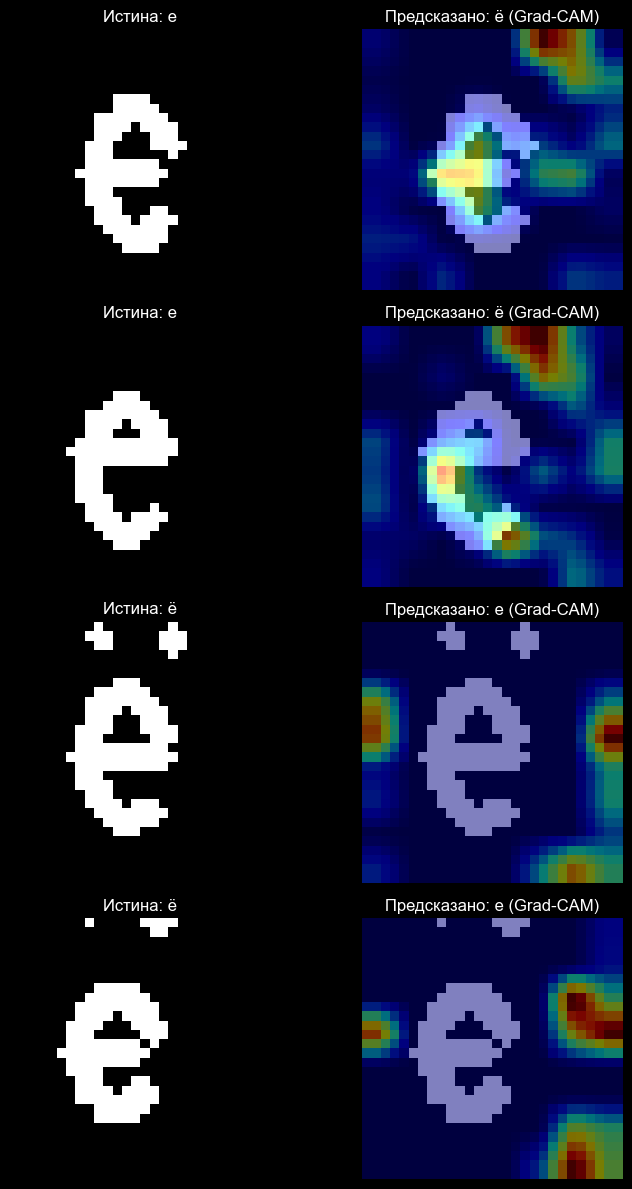

In [7]:
# 3. Детальный разбор ошибок
print("Ошибки Baseline:")
visualize_failure_cases(model_baseline, val_loader, val_dataset, device, num_cases=4)

Ошибки BG Loss:


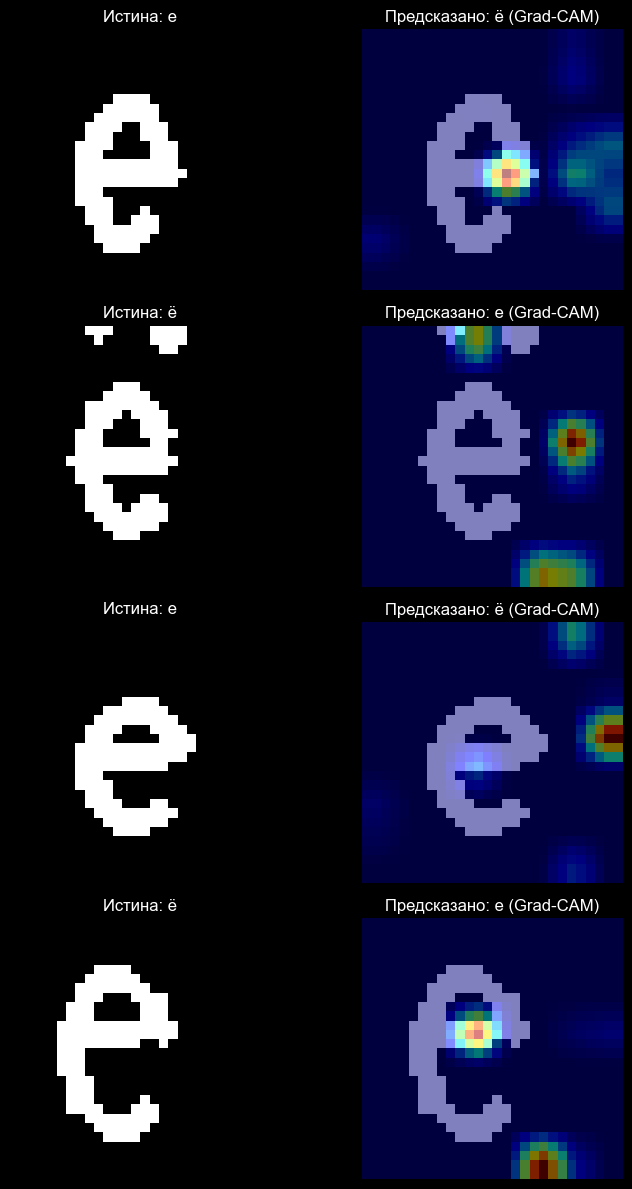

In [8]:
print("Ошибки BG Loss:")
visualize_failure_cases(model_bg, val_loader, val_dataset, device, num_cases=4)